In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# A. Computer Vision Part


## 1 Variational autoencoders 

### 1.1 Latent Variable Models


### 1.2 Decoder: The Generative Part of the VAE

#### Question 1: Steps for Sampling from the VAE Model

1. **Sample the Latent Variable $ z_n $:**
   - The latent variable $ z_n $ is assumed to follow a standard normal distribution, $ p(z_n) = N(0, I_D) $, where $ I_D $ is the identity matrix of dimensionality $ D $.
   - Sample $ z_n $ from a multivariate normal distribution with mean 0 $ and $ covariance matrix $ I_D $:
     $$
     z_n \sim N(0, I_D)
     $$

2. **Pass the Latent Variable $ z_n $ Through the Decoder:**
   - The decoder is a neural network parameterized by $ \theta $, denoted as $ f_\theta $. This network takes the latent variable $ z_n $ as input $ and $ produces the parameters for the Bernoulli distributions over the pixels of the image $ x_n $.
   - For each image $ x_n $, the decoder outputs a vector of means $ f_\theta(z_n) \in [0, 1]^M $, where $ M $ is the number of pixels in the image. These means represent the parameters of the Bernoulli distributions for each pixel.

3. **Sample the Observed Data $ x_n $:**
   - Once the means are obtained from the decoder, you sample each pixel $ x_n^{(m)} $ from the corresponding Bernoulli distribution:
     $$
     x_n^{(m)} \sim Bern(f_\theta(z_n)^{(m)})
     $$
     where $ f_\theta(z_n)^{(m)} $ is the probability of the $ m $-th pixel being 1. This means you independently sample each pixel from a Bernoulli distribution with the mean given by the decoder's output.

4. **Repeat for Each Data Point:**
   - Repeat the above steps for each data point in your dataset $ D $, i.e., for each $ n \in \{1, 2, \dots, N\} $, where $ N $ is the number of samples in the dataset.



#### Question 2: Steps for Sampling from the VAE Model

Monte-Carlo integration is inefficient for training VAE models because it requires sampling a large number of latent variables $ z_n $ to accurately approximate the expectation $ \mathbb{E}_{p(z_n)}[p(x_n | z_n)] $. As the dimensionality of the latent space $ D $ increases, the number of samples $ L $ required to achieve an accurate approximation grows exponentially. This is due to the curse of dimensionality, where the volume of the space increases rapidly as the number of dimensions increases, making it harder to cover the space with a finite number of samples. As a result, the computational cost of Monte-Carlo integration becomes prohibitive, especially for high-dimensional latent spaces, which makes it impractical for training VAEs.



### 1.3 KL Divergence


#### Question 3: KL Divergence for Univariate Gaussians

Let $ p(x) = N$mu_p, \sigma_p^2) $ and $ q(x) = N$mu_q, \sigma_q^2) $. , we know that the Kullback-Leibler (KL) divergence between these two distributions can be written as:

$$
D_{KL}(p || q) = -\int p(x) \log q(x) \, dx + \int p(x) \log p(x) \, dx
$$

The integration is performed over the entire real line. We also know that:

$$
\int p(x) \log p(x) \, dx = -\frac{1}{2} \left( 1 + \log 2\pi \sigma_p^2 \right)
$$

Thus, we can focus on the term $ \int p(x) \log q(x) \, dx $. We can write this term as:

$$
-\int p(x) \log \left( \frac{1}{\sqrt{2\pi \sigma_q^2}} e^{-\frac{(x - \mu_q)^2}{2 \sigma_q^2}} \right) dx
$$

This expression can be separated into two parts:

$$
\frac{1}{2} \log (2\pi \sigma_q^2) - \int p(x) \log e^{-\frac{(x - \mu_q)^2}{2 \sigma_q^2}} \, dx
$$

Taking the logarithm inside the integral gives:

$$
\frac{1}{2} \log (2\pi \sigma_q^2) - \int p(x) \left( -\frac{(x - \mu_q)^2}{2 \sigma_q^2} \right) dx
$$

We can separate the sums and take $ \frac{1}{2 \sigma_q^2} $ out of the integral:

$$
\frac{1}{2} \log (2\pi \sigma_q^2) + \frac{\int p(x) x^2 \, dx - \int p(x) 2 x \mu_q \, dx + \int p(x) {\mu_q^2} \, dx}{2 \sigma_q^2}
$$

Now, let $ \langle \cdot \rangle $ denote the expectation operator under $ p(x) $. We can rewrite the above expression as:

$$
\frac{1}{2} \log (2\pi \sigma_q^2) + \frac{\langle x^2 \rangle - 2 \langle x \rangle \mu_q + \mu_q^2}{2 \sigma_q^2}
$$

We know that the variance of $ x $, $ \text{Var}(x) $, is given by $ \langle x^2 \rangle - \langle x \rangle^2 $. Therefore:

$$
\langle x^2 \rangle = \sigma_p^2 + \mu_p^2
$$

Substituting this into the equation, we get:

$$
\frac{1}{2} \log (2\pi \sigma_q^2) + \frac{\sigma_p^2 + \mu_p^2 - 2 \mu_p \mu_q + \mu_q^2}{2 \sigma_q^2}
$$

Finally, we can simplify the expression as:

$$
\frac{1}{2} \log (2\pi \sigma_q^2) + \frac{\sigma_p^2 + \left( \mu_p - \mu_q \right)^2}{2 \sigma_q^2}
$$

Thus, the KL divergence between the two Gaussian distributions $ p(x) = N$mu_p, \sigma_p^2) $ and $ q(x) = N$mu_q, \sigma_q^2) $ is:

$$
D_{KL}(q || p) = \log \frac{\sigma_p}{\sigma_q} + \frac{\sigma_q^2 + $mu_q - \mu_p)^2}{2\sigma_p^2} - \frac{1}{2}
$$


Now, let's consider two examples where the KL divergence is either very small or very large:

#### Example 1: Very Small KL Divergence
- Let $ \mu_q = 0 $, $ \mu_p = 0 $, $ \sigma_q = 1 $, and $ \sigma_p = 1 $.
- In this case, both distributions are identical, so the KL divergence will be zero (or very small).

$$
D_{KL}(q || p) = \log \frac{1}{1} + \frac{1^2 + (0 - 0)^2}{2 \cdot 1^2} - \frac{1}{2} = 0
$$

#### Example 2: Very Large KL Divergence
- Let $ \mu_q = 0 $, $ \mu_p = 5 $, $ \sigma_q = 1 $, and $ \sigma_p = 1 $.
- Here, the means are significantly different, so the KL divergence will be large.

$$
D_{KL}(q || p) = \log \frac{1}{1} + \frac{1^2 + (0 - 5)^2}{2 \cdot 1^2} - \frac{1}{2} = \frac{25}{2} - \frac{1}{2} = 12
$$


### 1.4 The Encoder: $q_ϕ(z_n|x_n)$ - Efficiently evaluating the integral



#### Question 4: Explanation of the ELBO and Why It Is a Lower Bound

In **Eq. 16**, we have the relationship:

$$
\log p(x_n) - D_{KL}(q(Z|x_n) || p(Z|x_n)) = \mathbb{E}_{q(z|x_n)}[\log p(x_n | z)] - D_{KL}(q(Z|x_n) || p(Z))
$$

To understand why the right-hand side is a **lower bound** of the log-probability $\log p(x_n)$, we need to consider the following points:

1. **KL Divergence is Always Non-negative:**
   The Kullback-Leibler (KL) divergence, $ D_{KL}(q(Z|x_n) || p(Z|x_n)) $, is always non-negative. This is a fundamental property of KL divergence, which measures the difference between two probability distributions. Since $ D_{KL}(q(Z|x_n) || p(Z|x_n)) \geq 0 $, it follows that:

   $$
   \log p(x_n) \geq \mathbb{E}_{q(z|x_n)}[\log p(x_n | z)] - D_{KL}(q(Z|x_n) || p(Z))
   $$

   Therefore, the expression on the right-hand side of **Eq. 16** is a **lower bound** of the true log-likelihood $ \log p(x_n) $.

2. **The Bound Comes from Approximating the True Posterior:**
   The true posterior distribution $ p(Z|x_n) $ is difficult to compute directly. To make the problem tractable, we approximate the posterior with a variational distribution $ q(Z|x_n) $, which leads to the KL divergence term $ D_{KL}(q(Z|x_n) || p(Z|x_n)) $. This term quantifies the difference between the true posterior and the approximate posterior. Since this divergence is non-negative, the ELBO provides a lower bound on the log-likelihood.

---

#### Why Optimize the Lower Bound Instead of the Log-Probability Directly?

Optimizing the log-probability $ \log p(x_n) $ directly is not feasible because the true posterior $ p(Z|x_n) $ is intractable to compute. This is where the **variational approximation** $ q(Z|x_n) $ comes in. By optimizing the **Evidence Lower Bound (ELBO)**, we are effectively optimizing a tractable surrogate for the log-likelihood that involves terms we can compute efficiently.

- **Direct optimization of $\log p(x_n) $ requires computing $ p(Z|x_n) $,** which is difficult or impossible in many cases, especially when the model involves latent variables (like in VAEs).
- **The ELBO is a computable lower bound** that can be optimized using Monte Carlo sampling and variational inference techniques. By optimizing the ELBO, we indirectly improve the log-likelihood $ \log p(x_n) $, even though we cannot compute it directly.

Thus, we **optimize the ELBO** because it provides a feasible way to improve the model's performance by approximating the true log-likelihood with a lower bound that can be computed and optimized efficiently.


#### Question 5: Explanation of the Two Outcomes When the Lower Bound is Pushed Up

In **Eq. 16**, the relationship is expressed as:

$$
\log p(x_n) - D_{KL}(q(Z|x_n) || p(Z|x_n)) = \mathbb{E}_{q(z|x_n)}[\log p(x_n | z)] - D_{KL}(q(Z|x_n) || p(Z)).
$$

When the **lower bound** (right-hand side) is optimized and pushed closer to $ \log p(x_n) $, two outcomes can occur:

1. **The KL Divergence $ D_{KL}(q(Z|x_n) || p(Z|x_n)) $ Decreases:**
   - A smaller KL divergence indicates that the variational distribution $ q(Z|x_n) $ becomes a better approximation of the true posterior $ p(Z|x_n) $. 
   - This means the model is learning a more accurate representation of the latent variables $ Z $ given the observed data $ x_n $, improving the quality of the approximate posterior.

2. **The Log-Likelihood $ \log p(x_n) $ Increases:**
   - As the lower bound is pushed up, it approaches the true log-likelihood $ \log p(x_n) $, which measures how well the generative model explains the observed data $ x_n $.
   - This reflects an overall improvement in the model's ability to fit the data, meaning the generative model $ p(x_n | Z) $ and the prior $ p(Z) $ are better aligned with the observed data distribution.




### 1.5 Specifying the Encoder $q_ϕ(z_n|x_n)$


#### Question 6: Explanation of Reconstruction and Regularization Terms in the Loss Function

The loss function for VAEs, as rewritten in **Eq. 20**, is expressed as:

$$
L = \frac{1}{N} \sum_{n=1}^N \left( L_{\text{recon}, n} + L_{\text{reg}, n} \right),
$$

where:

1. **Reconstruction Loss**:  
   $ L_{\text{recon}, n} = -\mathbb{E}_{q_\phi(z|x_n)}[\log p_\theta(x_n|Z)] $

2. **Regularization Loss**:  
   $ L_{\text{reg}, n} = D_{KL}(q_\phi(Z|x_n) || p_\theta(Z)) $

---

##### 1. **Reconstruction Loss $ L_{\text{recon}, n} $**
- This term measures how well the decoder $ p_\theta(x_n|Z) $ can reconstruct the input data $ x_n $ from the latent variable $ Z $ sampled from the approximate posterior $ q_\phi(Z|x_n) $.

  - The decoder attempts to generate a reconstruction of $ x_n $ given $ Z $. The negative log-likelihood $ -\log p_\theta(x_n|Z) $ penalizes the model when the reconstructed data differs from the original data.
  - Minimizing this term encourages the model to produce reconstructions $ \hat{x}_n $ that are as close as possible to the true $ x_n $.

---

##### 2. **Regularization Loss $ L_{\text{reg}, n} $**
-  This term measures how closely the approximate posterior $ q_\phi(Z|x_n) $ aligns with the prior $ p_\theta(Z) $, using the KL divergence.

  - The KL divergence acts as a regularizer, ensuring that the latent space $ Z $ follows the structure of the prior $ p_\theta(Z) $.
  - Without this term, the model might overfit the data by allowing $ q_\phi(Z|x_n) $ to deviate significantly from the prior, resulting in poor generalization.






#### Question 7: Final Objective for Minimizing the Loss $ L $

The final objective $ L $ is defined as the sum of the reconstruction and regularization terms over all data points:

$$
L = \sum_{n=1}^N \left( L_{\text{recon}, n} + L_{\text{reg}, n} \right),
$$

where $ L_{\text{recon}, n} $ and $ L_{\text{reg}, n} $ are the reconstruction and regularization losses for each data point $ n $. Below, we derive the explicit expressions for these terms.

---

##### 1. **Reconstruction Loss $ L_{\text{recon}, n} $**

The reconstruction loss is defined as:

$$
L_{\text{recon}, n} = -\mathbb{E}_{q_\phi(z|x_n)}[\log p_\theta(x_n|Z)].
$$

Using the fact that $ Z \sim q_\phi(z|x_n) = \mathcal{N}(z; \mu_\phi(x_n), \text{diag}(\Sigma_\phi(x_n))) $, we approximate the expectation with a single sample $ z \sim q_\phi(z|x_n) $:

$$
L_{\text{recon}, n} \approx -\log p_\theta(x_n|z),
$$

where $ z $ is sampled as:

$$
z = \mu_\phi(x_n) + \epsilon \odot \sqrt{\Sigma_\phi(x_n)}, \quad \epsilon \sim \mathcal{N}(0, I).
$$

Here:
- $ \mu_\phi(x_n) $ is the mean of the approximate posterior.
- $ \Sigma_\phi(x_n) $ is the diagonal covariance matrix of the approximate posterior.
- $ \odot $ denotes element-wise multiplication.

---

##### 2. **Regularization Loss $ L_{\text{reg}, n} $**

The regularization loss is the KL divergence between the approximate posterior $ q_\phi(z|x_n) $ and the prior $ p_\theta(z) $. For a standard normal prior $ p_\theta(z) = \mathcal{N}(z; 0, I) $ and a Gaussian posterior $ q_\phi(z|x_n) = \mathcal{N}(z; \mu_\phi(x_n), \text{diag}(\Sigma_\phi(x_n))) $, the KL divergence can be computed as:

$$
L_{\text{reg}, n} = D_{KL}(q_\phi(z|x_n) || p_\theta(z)),
$$

which simplifies to:

$$
L_{\text{reg}, n} = \frac{1}{2} \sum_{i=1}^D \left[ 1 + \log \Sigma_{\phi, i}(x_n) - \mu_{\phi, i}^2(x_n) - \Sigma_{\phi, i}(x_n) \right],
$$

where:
- $ D $ is the dimensionality of the latent space.
- $ \mu_{\phi, i}(x_n) $ is the $ i $-th element of the mean vector $ \mu_\phi(x_n) $.
- $ \Sigma_{\phi, i}(x_n) $ is the $ i $-th diagonal element of the covariance matrix $ \Sigma_\phi(x_n) $.

---

##### Final Objective

Combining the two terms, the final loss $ L $ becomes:

$$
L \approx \sum_{n=1}^N \left[ -\log p_\theta(x_n|z) + \frac{1}{2} \sum_{i=1}^D \left( 1 + \log \Sigma_{\phi, i}(x_n) - \mu_{\phi, i}^2(x_n) - \Sigma_{\phi, i}(x_n) \right) \right],
$$

where:
- $ z = \mu_\phi(x_n) + \epsilon \odot \sqrt{\Sigma_\phi(x_n)}, \quad \epsilon \sim \mathcal{N}(0, I) $,
- $ \log p_\theta(x_n|z) $ is the log-likelihood of the reconstructed data given $ z $, often modeled as a Gaussian or Bernoulli distribution depending on the data type.

This is the final objective we minimize to train the VAE.


#### Question 8: Why Sampling Prevents Computing Gradients

When we sample from $ q_\phi(z_n|x_n) $, the sampling operation introduces stochasticity, which makes it non-differentiable. The gradients of the loss $ \nabla_\phi L $ require backpropagating through the sampling step, but since sampling is a discrete or random operation, it disrupts the computation of gradients. Specifically, the parameters $ \phi $ that define $ q_\phi(z_n|x_n) $ (e.g., the mean $ \mu_\phi(x_n) $ and variance $ \Sigma_\phi(x_n) $) cannot be directly updated through standard backpropagation due to the randomness in the sampling process.

---

#### How the Reparameterization Trick Solves This

The reparameterization trick reformulates the sampling process to make it differentiable. Instead of sampling $ z $ directly from $ q_\phi(z_n|x_n) $, we express $ z $ as a deterministic function of $ \phi $ and a source of randomness that is independent of $ \phi $. For a Gaussian posterior $ q_\phi(z_n|x_n) = \mathcal{N}(z; \mu_\phi(x_n), \text{diag}(\Sigma_\phi(x_n))) $, we rewrite the sampling process as:

$$
z = \mu_\phi(x_n) + \epsilon \odot \sqrt{\Sigma_\phi(x_n)}, \quad \epsilon \sim \mathcal{N}(0, I).
$$

Here:
- $ \epsilon $ is sampled from a standard normal distribution, which is independent of $ \phi $.
- The deterministic transformation $ \mu_\phi(x_n) + \epsilon \odot \sqrt{\Sigma_\phi(x_n)} $ depends on $ \phi $.

By reparameterizing in this way, the randomness is isolated in $ \epsilon $, and the parameters $ \phi $ remain in a differentiable computational graph. This allows gradients to flow through $ \mu_\phi(x_n) $ and $ \Sigma_\phi(x_n) $ during backpropagation, enabling optimization of the variational parameters $ \phi $.



### 1.7 Putting things together: Building a VAE

#### **Question 9: Build a Variational Autoencoder (VAE) and Train on Binarized MNIST Dataset**

To implement a Variational Autoencoder (VAE) with an MLP-based encoder and decoder, follow these steps:

##### **Encoder Architecture:**
- **Input Layer**: 784 units (flattened 28x28 MNIST image)
- **Hidden Layers**: Two fully connected layers with 400 units each, followed by ReLU activations.
- **Latent Space**: The output consists of two vectors:
  - **Mean (μ)**: 20 units
  - **Log-Variance (logσ²)**: 20 units
  This represents the latent space $ z $ of dimension 20.

##### **Decoder Architecture:**
- **Input Layer**: Latent vector $ z $ of size 20.
- **Hidden Layers**: Two fully connected layers with 400 units each, followed by ReLU activations.
- **Output Layer**: 784 units (same size as the input image), with a sigmoid activation to output pixel values between 0 and 1 (binarized).

##### **Hyperparameters:**
- **Latent Space Dimension**: 20 (size of $ z $)
- **Learning Rate**: $ 1 \times 10^{-3} $
- **Batch Size**: 128
- **Optimizer**: Adam
- **Number of Epochs**: 80
- **Loss Function**: The VAE loss is composed of two parts:
  1. **Reconstruction Loss**: Binary cross-entropy between the original and reconstructed image.
  2. **KL Divergence**: Measures the divergence between the learned latent distribution and a standard normal distribution.

##### **Training Steps:**
1. **Forward Pass**: Pass the input through the encoder to obtain the mean and log-variance of the latent distribution. Sample from this distribution using the reparameterization trick.
2. **Reconstruction**: Pass the latent variable through the decoder to reconstruct the input image.
3. **Loss Calculation**: Compute the reconstruction loss (binary cross-entropy) and the KL divergence.
4. **Backpropagation**: Use the Adam optimizer to minimize the total loss (reconstruction loss + KL divergence).
5. **Training Loop**: Repeat the above steps for 80 epochs, updating the model parameters.

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 17902377.30it/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 477581.55it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 4414116.07it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 5840137.57it/s]


Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw

Epoch [1/80], Loss: 176.64455325520834


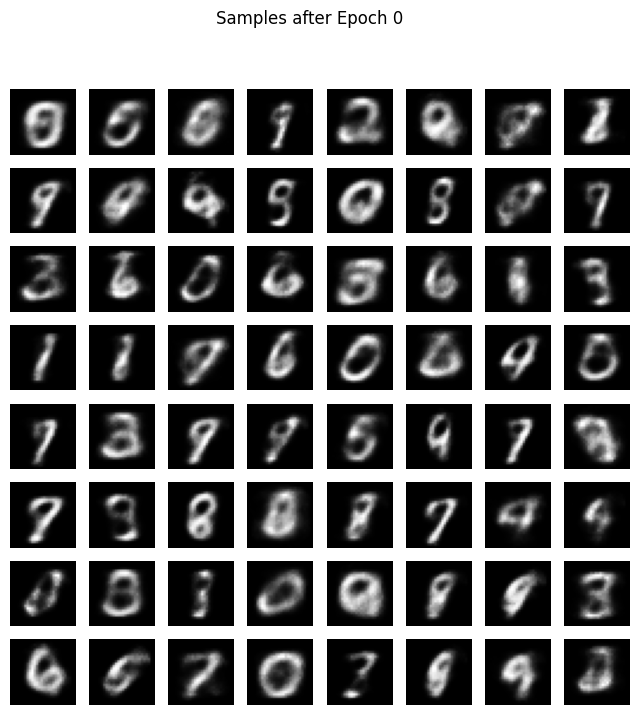

Epoch [2/80], Loss: 129.0568871419271
Epoch [3/80], Loss: 117.25743842773437
Epoch [4/80], Loss: 112.3612916829427
Epoch [5/80], Loss: 109.36892648111979
Epoch [6/80], Loss: 107.44808706054687
Epoch [7/80], Loss: 106.08999860026042
Epoch [8/80], Loss: 105.07392561848958
Epoch [9/80], Loss: 104.24728141276042
Epoch [10/80], Loss: 103.52263011067708
Epoch [11/80], Loss: 102.91170545247395


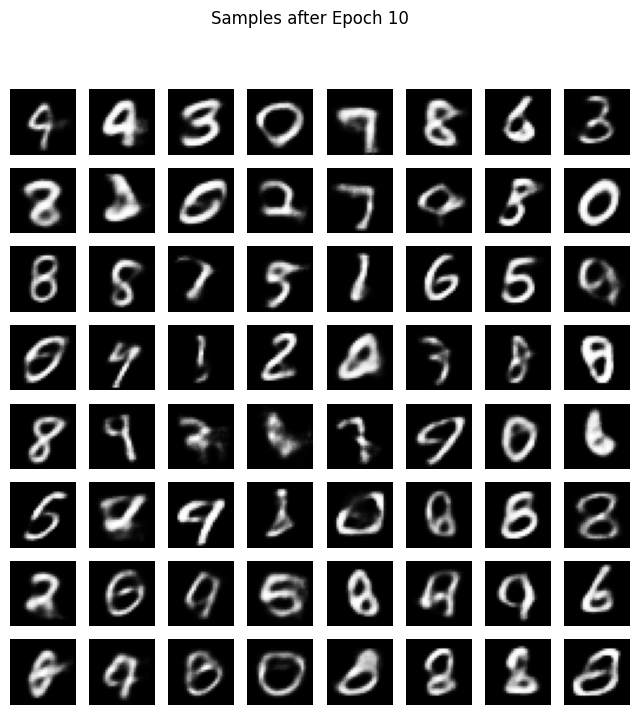

Epoch [12/80], Loss: 102.35850183919271
Epoch [13/80], Loss: 101.95166687825521
Epoch [14/80], Loss: 101.45837718098959
Epoch [15/80], Loss: 101.09347229817709
Epoch [16/80], Loss: 100.79973637695312
Epoch [17/80], Loss: 100.56202734375
Epoch [18/80], Loss: 100.28924895833333
Epoch [19/80], Loss: 100.03497685546876
Epoch [20/80], Loss: 99.83346578776042
Epoch [21/80], Loss: 99.60887872721354
Epoch [22/80], Loss: 99.44928678385416
Epoch [23/80], Loss: 99.2344919921875
Epoch [24/80], Loss: 99.06350870768229
Epoch [25/80], Loss: 98.92475431315104
Epoch [26/80], Loss: 98.74923600260416
Epoch [27/80], Loss: 98.64916015625
Epoch [28/80], Loss: 98.50413160807291
Epoch [29/80], Loss: 98.38646236979167
Epoch [30/80], Loss: 98.30792395833333
Epoch [31/80], Loss: 98.1635876953125
Epoch [32/80], Loss: 98.05281227213541
Epoch [33/80], Loss: 97.90733994140625
Epoch [34/80], Loss: 97.78833950195313
Epoch [35/80], Loss: 97.78311559244791
Epoch [36/80], Loss: 97.64162146809896
Epoch [37/80], Loss: 97.5

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 128
epochs = 81  # Increase to 80 epochs
zdim = 20
learning_rate = 1e-3

# Data loading and preprocessing
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_data = datasets.MNIST('.', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Define the Encoder and Decoder networks
class Encoder(nn.Module):
    def __init__(self, zdim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3_mu = nn.Linear(256, zdim)
        self.fc3_logvar = nn.Linear(256, zdim)

    def forward(self, x):
        h1 = torch.relu(self.fc1(x))
        h2 = torch.relu(self.fc2(h1))
        mu = self.fc3_mu(h2)
        logvar = self.fc3_logvar(h2)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, zdim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(zdim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, 784)

    def forward(self, z):
        h1 = torch.relu(self.fc1(z))
        h2 = torch.relu(self.fc2(h1))
        return torch.sigmoid(self.fc3(h2)).view(-1, 784)

# Reparameterization Trick
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# VAE Model
class VAE(nn.Module):
    def __init__(self, zdim):
        super(VAE, self).__init__()
        self.encoder = Encoder(zdim)
        self.decoder = Decoder(zdim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    def loss_function(self, x, x_recon, mu, logvar):
        # Reconstruction Loss (binary cross-entropy)
        recon_loss = nn.BCELoss(reduction='sum')(x_recon, x)
        # KL Divergence Loss
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + kl_div

# Instantiate the model and optimizer
vae = VAE(zdim)
optimizer = optim.Adam(vae.parameters(), lr=learning_rate)

# Function to plot 64 samples
def plot_samples(vae, epoch, device='cpu'):
    vae.eval()
    with torch.no_grad():
        # Sample from the latent space
        z = torch.randn(64, zdim).to(device)
        samples = vae.decoder(z).cpu()
        samples = samples.view(64, 1, 28, 28)
        
        # Plot the samples
        fig, axes = plt.subplots(8, 8, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            ax.imshow(samples[i].squeeze(), cmap='gray')
            ax.axis('off')
        plt.suptitle(f'Samples after Epoch {epoch}')
        plt.show()

# Training loop
for epoch in range(epochs):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.view(-1, 784)  # Flatten the image
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(data)
        loss = vae.loss_function(data, x_recon, mu, logvar)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_loss / len(train_loader.dataset)}')

    # Plot samples at specific epochs
    if epoch == 0:  # Before training
        plot_samples(vae, epoch)
    elif epoch == 10:  # After 10 epochs
        plot_samples(vae, epoch)
    elif epoch == 80:  # After 80 epochs
        plot_samples(vae, epoch)

# Save the trained model
torch.save(vae.state_dict(), 'vae_mnist.pth')


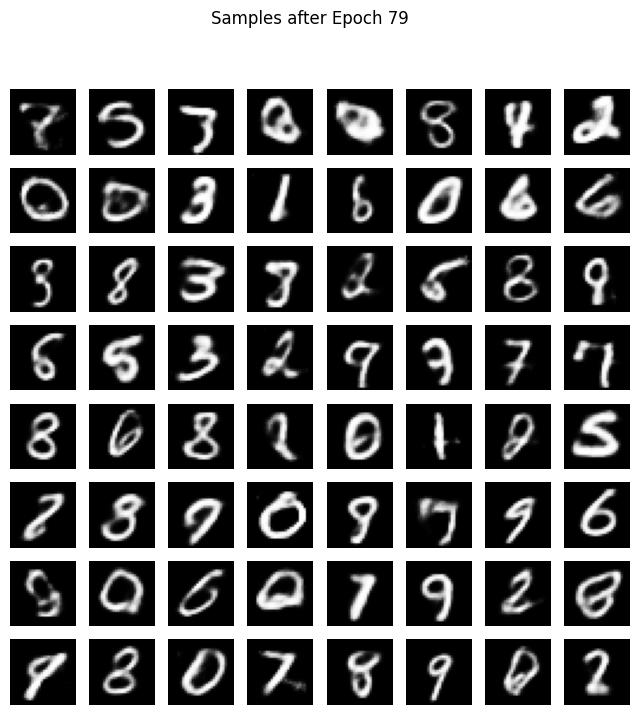

In [6]:
plot_samples(vae, epoch)

#### **Question 10: Plot 64 Samples from the VAE at Different Training Points**

To observe the evolution of the generated samples, we will plot 64 samples from the VAE at three stages during training:


- **Before Training**: The generated images are random and do not exhibit any discernible structures.
- **After 10 Epochs**: The generated images begin to show some structure, but they still possess blurry and incomplete features.
- **After 80 Epochs**: The generated images are more coherent, with recognizable digits and clearer details; however, they do not seem to have fully converged.

---

## 2 Diffusion

#### Question 11:

##### 1. **Log Marginal Likelihood:**

We want to express the log marginal likelihood of the data $ x $, which can be written as:

$$
\log p(x) = \log \left( \int p(x, z_{1:T}) \, dz_{1:T} \right)
$$

##### 2. **Factorization of the Joint Distribution:**

From the given joint distribution for the Markovian HVAE, we have:

$$
p(x, z_{1:T}) = p(z_T) p_\theta(x | z_1) \prod_{t=2}^{T} p_\theta(z_{t-1} | z_t)
$$

This means that the joint distribution can be factorized into a prior term $ p(z_T) $, a likelihood term $ p_\theta(x | z_1) $, and a set of transition terms $ p_\theta(z_{t-1} | z_t) $ for $ t = 2, \dots, T $.

##### 3. **Variational Posterior:**

Similarly, the variational posterior is factorized as:

$$
q_\phi(z_{1:T} | x) = q_\phi(z_1 | x) \prod_{t=2}^{T} q_\phi(z_t | z_{t-1})
$$

##### 4. **ELBO Derivation:**

We can lower bound the log marginal likelihood using the ELBO. The ELBO is derived by adding and subtracting the log of the variational posterior $ q_\phi(z_{1:T} | x) $:

$$
\log p(x) = \log \left( \int p(x, z_{1:T}) \, dz_{1:T} \right)
$$
$$
= \log \left( \int q_\phi(z_{1:T} | x) \frac{p(x, z_{1:T})}{q_\phi(z_{1:T} | x)} \, dz_{1:T} \right)
$$
$$
\geq \int q_\phi(z_{1:T} | x) \log \left( \frac{p(x, z_{1:T})}{q_\phi(z_{1:T} | x)} \right) dz_{1:T}
$$
$$
= \mathbb{E}_{q_\phi(z_{1:T} | x)} \left[ \log \frac{p(x, z_{1:T})}{q_\phi(z_{1:T} | x)} \right]
$$
<!-- $$
= \mathbb{E}_{q_\phi(z_{1:T} | x)} \left[ \log p(x, z_{1:T}) - \log q_\phi(z_{1:T} | x) \right]
$$ -->

<!-- ### 5. **Substitute the Joint and Posterior Factorizations:**

Now, we substitute the factorizations for $ p(x, z_{1:T}) $ and $ q_\phi(z_{1:T} | x) $:

$$
= \mathbb{E}_{q_\phi(z_{1:T} | x)} \left[ \log \left( p(z_T) p_\theta(x | z_1) \prod_{t=2}^{T} p_\theta(z_{t-1} | z_t) \right) - \log \left( q_\phi(z_1 | x) \prod_{t=2}^{T} q_\phi(z_t | z_{t-1}) \right) \right]
$$

### 6. **Simplify the Expression:**

Breaking this down, we get:

$$
= \mathbb{E}_{q_\phi(z_{1:T} | x)} \left[ \log p(z_T) + \log p_\theta(x | z_1) + \sum_{t=2}^{T} \log p_\theta(z_{t-1} | z_t) - \log q_\phi(z_1 | x) - \sum_{t=2}^{T} \log q_\phi(z_t | z_{t-1}) \right]
$$

### Final ELBO Expression:

Thus, the ELBO for the Markovian Hierarchical Variational Autoencoder is:

$$
\log p(x) \geq \mathbb{E}_{q_\phi(z_{1:T} | x)} \left[ \log p(z_T) + \log p_\theta(x | z_1) + \sum_{t=2}^{T} \log p_\theta(z_{t-1} | z_t) - \log q_\phi(z_1 | x) - \sum_{t=2}^{T} \log q_\phi(z_t | z_{t-1}) \right]
$$ -->


#### Question 12: Variational Diffusion Model (VDM) Process Description

The **Variational Diffusion Model (VDM)** is a generative model based on the **Markovian Hierarchical Variational Autoencoder (MHVAE)**, with three key restrictions:

1. **Latent Dimension Equals Data Dimension**: 
   The latent variable $ z_t $ at each timestep has the same dimension as the data $ x $, meaning the data is directly represented by the latent variable.

2. **Linear Gaussian Latent Encoder**: 
   The structure of the latent encoder at each timestep is fixed and follows a linear Gaussian model. Specifically, the latent variable $ z_t $ at each timestep $ t $ is drawn from a Gaussian distribution centered around the previous latent variable $ z_{t-1} $. This is mathematically represented as:
   $$
   q(z_t | z_{t-1}) = \mathcal{N} \left( z_t; \sqrt{\alpha_t} z_{t-1}, (1 - \alpha_t)I \right)
   $$
   where $ \alpha_t $ is a learnable coefficient that controls the variance of the latent distribution and may vary with the depth of the model. The Gaussian distribution captures the transition from one latent state to the next.

3. **Standard Gaussian at Final Timestep**: 
   The distribution of the latent at the final timestep $ T $ is a standard Gaussian distribution:
   $$
   p(z_T) = \mathcal{N}(z_T; 0, I)
   $$
   This ensures that the final latent variable follows a standard Gaussian distribution.

### Process (Architecture, Transformations, Inputs, and Outputs)

- **Architecture**: 
  The VDM follows a hierarchical structure where each latent variable $ z_t $ is conditioned on the previous latent $ z_{t-1} $, forming a Markov chain. The architecture can be viewed as a series of VAEs stacked on top of each other, with the key difference being the use of a Gaussian prior and transition model for the latent variables.
  
- **Transformations**: 
  The transformations involve passing the data through a series of latent variables, where each latent variable is updated based on the previous one. The data $ x $ is initially represented as $ z_0 $, and through the Markovian transitions, the model learns to transform $ z_0 $ into $ z_T $, which is drawn from a standard Gaussian distribution.

- **Inputs**: 
  The input to the VDM is the data $ x $, which is used to initialize the first latent variable $ z_0 $. This can be seen as a form of denoising or transformation through the diffusion process.

- **Outputs**: 
  The output of the model is a sequence of latent variables $ z_1, z_2, \dots, z_T $, where the final latent variable $ z_T $ follows a standard Gaussian distribution. The model also generates the data $ x $ by reversing the diffusion process, starting from the final latent $ z_T $ and iteratively transforming it back to $ z_0 $, which corresponds to the original data.



#### Question 13: Explanation of the Terms in the ELBO Formula (Equation 24)

The updated ELBO formula for the Variational Diffusion Model (VDM) is given as:

$$
\log p(z) = \mathbb{E}_{q(z_1|z_0)} \left[ \log p_\theta(z_0|z_1) \right]
- \mathbb{E}_{q(z_T|z_0)} \left[ \text{KL}(q(z_T|z_{T-1}) \| p(z_T)) \right]
- \sum_{t=1}^{T-1} \mathbb{E}_{q(z_{t-1}, z_{t+1}|z_0)} \left[ \text{KL}(q(z_t|z_{t-1}) \| p_\theta(z_t|z_{t+1})) \right]
$$

This formula can be broken into three key terms, each playing a distinct role:

---

##### **1. Reconstruction Term:**
$$
\mathbb{E}_{q(z_1|z_0)} \left[ \log p_\theta(z_0|z_1) \right]
$$

-This term ensures that the model can accurately reconstruct the data $ z_0 $ (the observed data) from the latent variable $ z_1 $. 
- It measures the likelihood of the observed data $ z_0 $ given the latent variable $ z_1 $, encouraging the decoder $ p_\theta $ to generate data that matches the original input.
- This term drives the generative capacity of the model, ensuring that the diffusion process can reverse back to the original data.

---

##### **2. Prior Matching Term:**
$$
\mathbb{E}_{q(z_T|z_0)} \left[ \text{KL}(q(z_T|z_{T-1}) \| p(z_T)) \right]
$$

- This term ensures that the latent variable $ z_T $ at the final timestep matches the prior distribution $ p(z_T) $, which is a standard Gaussian $ \mathcal{N}(0, I) $.
-  The Kullback-Leibler (KL) divergence penalizes deviations between the learned latent distribution $ q(z_T|z_{T-1}) $ and the standard Gaussian prior. This enforces a regularization that ensures the model's latent space is well-structured and compatible with the prior.
-  It helps maintain a consistent and interpretable latent space, crucial for sampling and generalization.

---

##### **3. Consistency Term:**
$$
\sum_{t=1}^{T-1} \mathbb{E}_{q(z_{t-1}, z_{t+1}|z_0)} \left[ \text{KL}(q(z_t|z_{t-1}) \| p_\theta(z_t|z_{t+1})) \right]
$$

-  This term enforces consistency between the forward and reverse transitions at each timestep $ t $. It ensures that the latent variable $ z_t $ generated by the forward process $ q(z_t|z_{t-1}) $ aligns with the reverse process $ p_\theta(z_t|z_{t+1}) $.
-  The KL divergence penalizes discrepancies between the two processes, ensuring that the diffusion model transitions are smooth and reversible.
-  This term is critical for maintaining the Markov property of the hierarchical latent structure and for ensuring that the reverse diffusion process accurately reconstructs the data.





#### Question 14: Derivation of Equation (26)

We are tasked with showing that $ z_t \sim \mathcal{N}(\sqrt{\bar{\alpha}_t} z_0, (1 - \bar{\alpha}_t)I) $, starting from the recursive reparameterization formula:

$$
z_t = \sqrt{\alpha_t} z_{t-1} + \sqrt{1 - \alpha_t} \epsilon, \quad \epsilon \sim \mathcal{N}(0, I).
$$

---

#### **Step 1: Expand $ z_t $ Recursively**
Using the reparameterization trick iteratively, we substitute $ z_{t-1} $ into the equation for $ z_t $:

$$
z_t = \sqrt{\alpha_t} \left( \sqrt{\alpha_{t-1}} z_{t-2} + \sqrt{1 - \alpha_{t-1}} \epsilon_{t-1} \right) + \sqrt{1 - \alpha_t} \epsilon_t,
$$

where $ \epsilon_t, \epsilon_{t-1} \sim \mathcal{N}(0, I) $.

Expanding further:

$$
z_t = \sqrt{\alpha_t \alpha_{t-1}} z_{t-2} + \sqrt{\alpha_t (1 - \alpha_{t-1})} \epsilon_{t-1} + \sqrt{1 - \alpha_t} \epsilon_t.
$$

By repeating this process, we can express $ z_t $ in terms of $ z_0 $:

$$
z_t = \sqrt{\alpha_t \alpha_{t-1} \cdots \alpha_1} z_0 + \sum_{i=1}^t \sqrt{1 - \alpha_i} \prod_{j=i+1}^t \sqrt{\alpha_j} \, \epsilon_i,
$$

where $ \prod_{j=i+1}^t \sqrt{\alpha_j} $ is the cumulative product of $ \sqrt{\alpha_j} $ for $ j > i $.

---

#### **Step 2: Define $ \bar{\alpha}_t $**
Define $ \bar{\alpha}_t $ as the cumulative product of $ \alpha_t $:

$$
\bar{\alpha}_t = \prod_{i=1}^t \alpha_i.
$$

Thus, the first term becomes:

$$
\sqrt{\bar{\alpha}_t} z_0.
$$

---

#### **Step 3: Variance of $ z_t $**
The second term involves a weighted sum of independent Gaussian noise terms $ \epsilon_i \sim \mathcal{N}(0, I) $. The variance of the weighted sum is given by the hint:

$$
\text{If } \epsilon \sim \mathcal{N}(0, I), \text{ then } (\alpha \epsilon_1 + \beta \epsilon_2) \sim \mathcal{N}(0, (\alpha^2 + \beta^2) I).
$$

For the second term:

$$
\text{Variance} = \sum_{i=1}^t \left( \prod_{j=i+1}^t \alpha_j \right) (1 - \alpha_i).
$$

This simplifies to:

$$
1 - \bar{\alpha}_t,
$$

since the cumulative product $ \prod_{j=i+1}^t \alpha_j $ accounts for the weights at each timestep.

---

#### **Step 4: Final Distribution**
Combining the mean and variance, we find that:

$$
z_t \sim \mathcal{N}(z_t; \sqrt{\bar{\alpha}_t} z_0, (1 - \bar{\alpha}_t)I).
$$

This matches Equation (26).


#### Question 15: Derivation and Interpretation of the Final Optimization Term

##### **Step 1: Plugging Equations (29) and (30) into Equation (28)**



The optimization objective is:

$$
\arg \min_\theta \frac{1}{2 \sigma_q^2(t)} \left\| \mu_\theta - \mu_q \right\|_2^2,
$$

where:
- $ \mu_q $ is given by Equation (29):
  $$
  \mu_q(z_t, z_0) = \frac{\sqrt{\alpha_t} (1 - \bar{\alpha}_{t-1}) z_t + \sqrt{\bar{\alpha}_{t-1}} (1 - \alpha_t) z_0}{1 - \bar{\alpha}_t}.
  $$

- $ \mu_\theta $ is given by Equation (30):
  $$
  \mu_\theta(z_t, t) = \frac{\sqrt{\alpha_t} (1 - \bar{\alpha}_{t-1}) z_t + \sqrt{\bar{\alpha}_{t-1}} (1 - \alpha_t) \hat{z}_\theta(z_t, t)}{1 - \bar{\alpha}_t}.
  $$

Substituting these expressions for $ \mu_q $ and $ \mu_\theta $ into the objective:

$$
\arg \min_\theta \frac{1}{2 \sigma_q^2(t)} \left\| 
\frac{\sqrt{\alpha_t} (1 - \bar{\alpha}_{t-1}) z_t + \sqrt{\bar{\alpha}_{t-1}} (1 - \alpha_t) \hat{z}_\theta(z_t, t)}{1 - \bar{\alpha}_t}
-
\frac{\sqrt{\alpha_t} (1 - \bar{\alpha}_{t-1}) z_t + \sqrt{\bar{\alpha}_{t-1}} (1 - \alpha_t) z_0}{1 - \bar{\alpha}_t}
\right\|_2^2.
$$

---

##### **Step 2: Simplify the Expression**

Factor out $ \frac{1}{1 - \bar{\alpha}_t} $ and focus on the difference between the terms involving $ \hat{z}_\theta(z_t, t) $ and $ z_0 $:

$$
\arg \min_\theta \frac{1}{2 \sigma_q^2(t)} \frac{1}{(1 - \bar{\alpha}_t)^2} \left\| 
\sqrt{\bar{\alpha}_{t-1}} (1 - \alpha_t) \left( \hat{z}_\theta(z_t, t) - z_0 \right)
\right\|_2^2.
$$

Simplify further:

$$
\arg \min_\theta \frac{1}{2 \sigma_q^2(t)} \frac{\bar{\alpha}_{t-1} (1 - \alpha_t)^2}{(1 - \bar{\alpha}_t)^2} \left\| \hat{z}_\theta(z_t, t) - z_0 \right\|_2^2.
$$

Since the prefactor is independent of $ \hat{z}_\theta $, the optimization reduces to minimizing the mean squared error between $ \hat{z}_\theta(z_t, t) $ and $ z_0 $:

$$
\arg \min_\theta \left\| \hat{z}_\theta(z_t, t) - z_0 \right\|_2^2.
$$

---

##### **Interpretation**

The final optimization term has the following interpretation:

1. **Matching the Neural Network Prediction to the Original Data:**
   The term $ \hat{z}_\theta(z_t, t) $ is the neural network's prediction of $ z_0 $, given $ z_t $ and the timestep $ t $. The optimization minimizes the squared difference between this prediction and the true $ z_0 $.

2. **Denoising Objective:**
   This can be interpreted as a denoising task where the model learns to predict the original data $ z_0 $ from a noisy intermediate state $ z_t $. The timestep $ t $ provides additional context to the neural network.

3. **Role in Diffusion Models:**
   By training the neural network to predict $ z_0 $, the model effectively learns the reverse diffusion process, which is crucial for generating samples from the learned data distribution.




### 2.1 Generate Image by learning the denoise

#### Question 16: Signal-to-Noise Ratio (SNR) at Timestep $ t $


The distribution $ q(z_t | z_0) $ is defined as:

$$
q(z_t | z_0) = \mathcal{N}(z_t; \sqrt{\bar{\alpha}_t} z_0, (1 - \bar{\alpha}_t) \mathbf{I}),
$$

where:
- $ \sqrt{\bar{\alpha}_t} z_0 $ is the mean,
- $ (1 - \bar{\alpha}_t) \mathbf{I} $ is the variance.


The signal-to-noise ratio is defined as:

$$
\text{SNR} = \frac{\mu^2}{\sigma^2},
$$

where:
- $ \mu^2 $ is the squared mean of the signal,
- $ \sigma^2 $ is the variance of the noise.


From $ q(z_t | z_0) $:
- Mean: $ \mu = \sqrt{\bar{\alpha}_t} z_0 $,
- Variance: $ \sigma^2 = 1 - \bar{\alpha}_t $.


Substituting into the SNR formula:

$$
\text{SNR} = \frac{\mu^2}{\sigma^2} = \frac{(\sqrt{\bar{\alpha}_t} z_0)^2}{1 - \bar{\alpha}_t}.
$$

Simplify:

$$
\text{SNR} = \frac{\bar{\alpha}_t z_0^2}{1 - \bar{\alpha}_t}.
$$


The SNR at timestep $ t $ is:

$$
\text{SNR}_t = \frac{\bar{\alpha}_t}{1 - \bar{\alpha}_t}.
$$

This result depends only on $ \bar{\alpha}_t $, which is the cumulative product of the noise scheduling coefficients $ \alpha_t $.


#### Question 17: Incorporating the SNR into the Optimization Term

##### **From Question 15**
The optimization term derived was:

$$
\text{arg min}_\theta \, D_{\text{KL}}(q(z_{t-1} | z_t, z_0) \, || \, p_\theta(z_{t-1} | z_t)) = \text{arg min}_\theta \, \frac{1}{2 \sigma_q^2(t)} \| \mu_\theta - \mu_q \|^2,
$$

where:
- $ \mu_q $ is the mean from Equation (29):
  $$
  \mu_q(z_t, z_0) = \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1}) z_t + \sqrt{\bar{\alpha}_{t-1}}(1 - \alpha_t) z_0}{1 - \bar{\alpha}_t}.
  $$
- $ \mu_\theta $ is the parameterized mean from Equation (30):
  $$
  \mu_\theta(z_t, t) = \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1}) z_t + \sqrt{\bar{\alpha}_{t-1}}(1 - \alpha_t) \hat{z}_\theta(z_t, t)}{1 - \bar{\alpha}_t}.
  $$
- $ \sigma_q^2(t) = \frac{(1 - \alpha_t)(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}. $

##### **Step 1: Express $ \sigma_q^2(t) $ in Terms of SNR**
From the definition of SNR:

$$
\text{SNR}_t = \frac{\bar{\alpha}_t}{1 - \bar{\alpha}_t}.
$$

Rewriting $ 1 - \bar{\alpha}_t $ in terms of SNR:

$$
1 - \bar{\alpha}_t = \frac{1}{1 + \text{SNR}_t}.
$$

Substituting this into $ \sigma_q^2(t) $:

$$
\sigma_q^2(t) = \frac{(1 - \alpha_t)(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} = (1 - \alpha_t)(1 - \bar{\alpha}_{t-1})(1 + \text{SNR}_t).
$$


The variance $ \sigma_q^2(t) $ depends on the noise schedule $ \alpha_t $, the cumulative noise $ \bar{\alpha}_{t-1} $, and the signal-to-noise ratio $ \text{SNR}_t $. 


1. **Noise Control**: The SNR dictates the relative weight of the signal ($ z_0 $) and the noise ($ z_t $) at each timestep. Higher SNR values indicate more signal dominance, while lower SNR values indicate higher noise dominance.

2. **Optimization Objective**: By incorporating SNR, the model learns to denoise $ z_t $ effectively by balancing the contributions of the signal ($ z_0 $) and noise. This ensures that the model generates samples that gradually resemble the data distribution as it progresses through the timesteps.

3. **Denoising Process**: The dependence on SNR highlights the gradual denoising nature of the diffusion process, where the model transitions from noisy latent variables $ z_t $ to the clean data $ z_0 $.

4. **Link to Variance Scheduling**: The SNR is inherently tied to the noise scheduling strategy ($ \alpha_t $), making it a critical parameter in controlling the quality and stability of the diffusion model.




### 2.2 Diffusion in practice

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/143M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage e

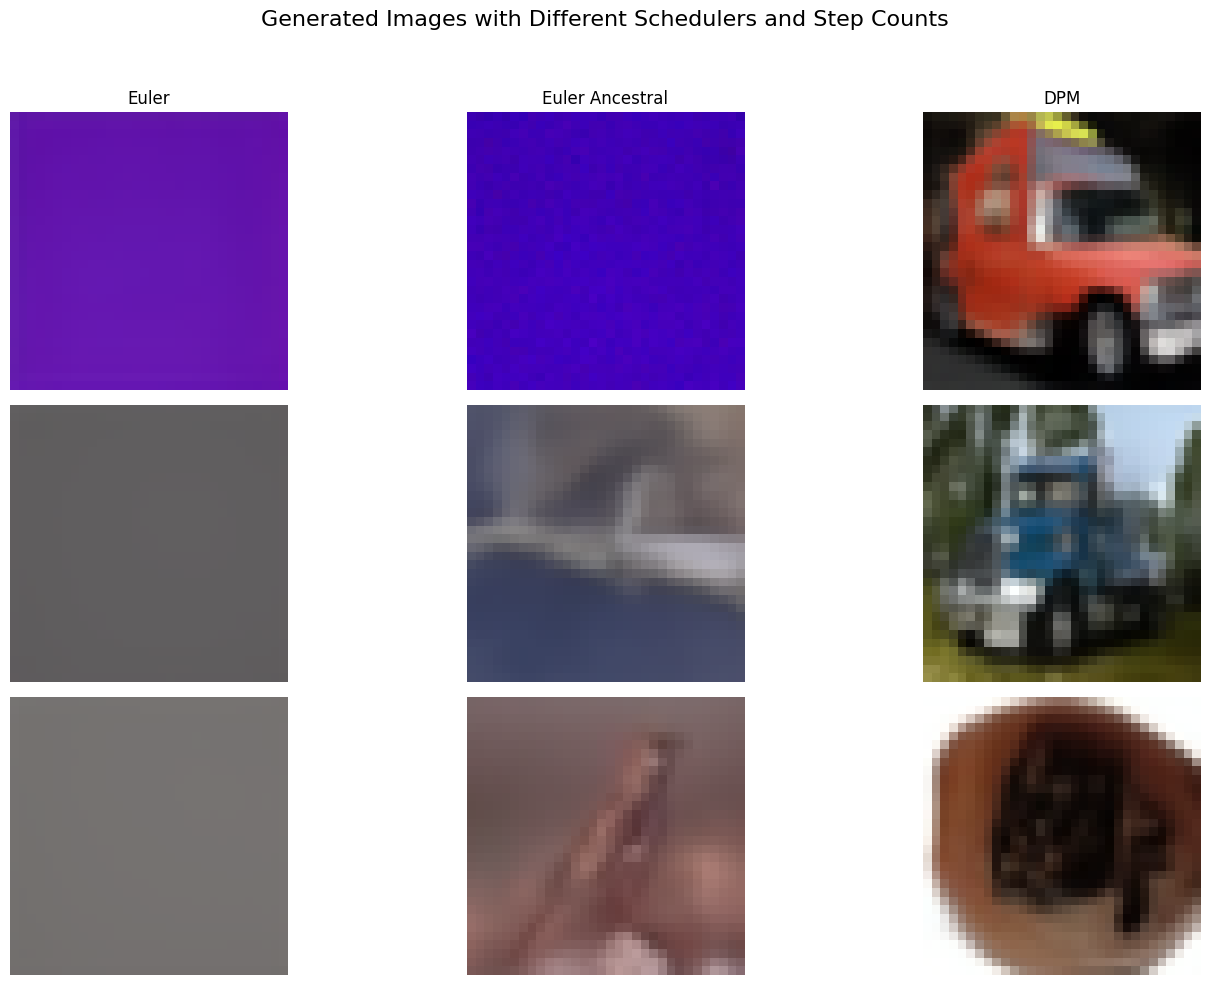

In [6]:
import torch
from diffusers import UNet2DModel, DDPMScheduler, EulerDiscreteScheduler, EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt

# Define the UNet model and schedulers
model = UNet2DModel.from_pretrained("google/ddpm-cifar10-32")
schedulers = {
    "Euler": EulerDiscreteScheduler.from_pretrained("google/ddpm-cifar10-32"),
    "Euler Ancestral": EulerAncestralDiscreteScheduler.from_pretrained("google/ddpm-cifar10-32"),
    "DPM": DPMSolverMultistepScheduler.from_pretrained("google/ddpm-cifar10-32"),
}

# Parameters
image_size = 32
num_steps_list = [10, 25, 50]
seed = 42
torch.manual_seed(seed)

# Create a grid of images
fig, axes = plt.subplots(len(num_steps_list), len(schedulers), figsize=(15, 10))
fig.suptitle("Generated Images with Different Schedulers and Step Counts", fontsize=16)

# Generate images for each scheduler and step count
for i, num_steps in enumerate(num_steps_list):
    for j, (scheduler_name, scheduler) in enumerate(schedulers.items()):
        scheduler.set_timesteps(num_steps)
        
        # Start with random noise
        noise = torch.randn(1, 3, image_size, image_size)
        image = noise
        
        # Reverse diffusion process
        for t in scheduler.timesteps:
            model_output = model(image, t)["sample"]
            image = scheduler.step(model_output, t, image)["prev_sample"]
        
        # Convert to image
        image = (image.clamp(-1, 1) + 1) / 2  # Normalize to [0, 1]
        image = (image * 255).byte()
        image = image.permute(0, 2, 3, 1).squeeze().numpy()
        image = Image.fromarray(image)
        
        # Plot the image
        axes[i, j].imshow(image)
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(scheduler_name, fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(f"{num_steps} steps", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [8]:
!pip install diffusers transformers


/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

tokenizer/merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

vae/config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

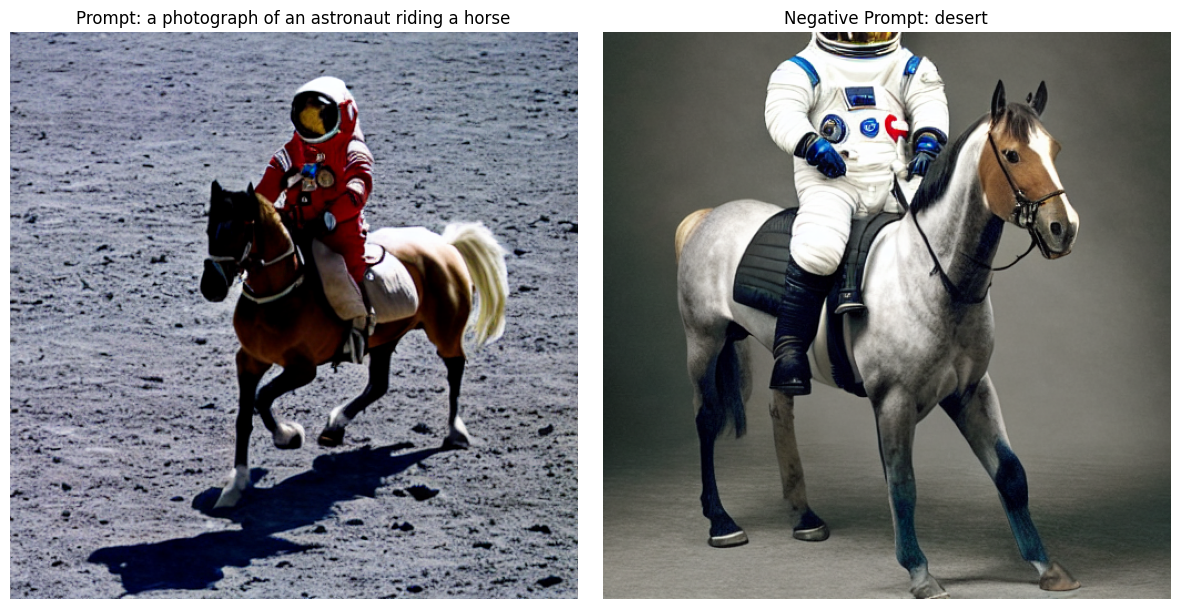

In [15]:
from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt
# Load the Stable Diffusion pipeline
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")
def generate_guided_image(prompt, negative_prompt, guidance_scale=7.5, num_inference_steps=50):
    # Generate an image with positive guidance
    image_pos = pipe(prompt, num_inference_steps=num_inference_steps, guidance_scale=guidance_scale).images[0]
    
    # Generate an image with negative guidance
    image_neg = pipe(prompt, num_inference_steps=num_inference_steps, negative_prompt=negative_prompt, guidance_scale=guidance_scale).images[0]
    
    return image_pos, image_neg


prompt = "a photograph of an astronaut riding a horse"
negative_prompt = "desert"  # Example of removing an object or concept
img_pos, img_neg = generate_guided_image(prompt, negative_prompt)

# Plot the images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_pos)
axes[0].axis("off")
axes[0].set_title(f"Prompt: {prompt}")

axes[1].imshow(img_neg)
axes[1].axis("off")
axes[1].set_title(f"Negative Prompt: {negative_prompt}")

plt.tight_layout()
plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

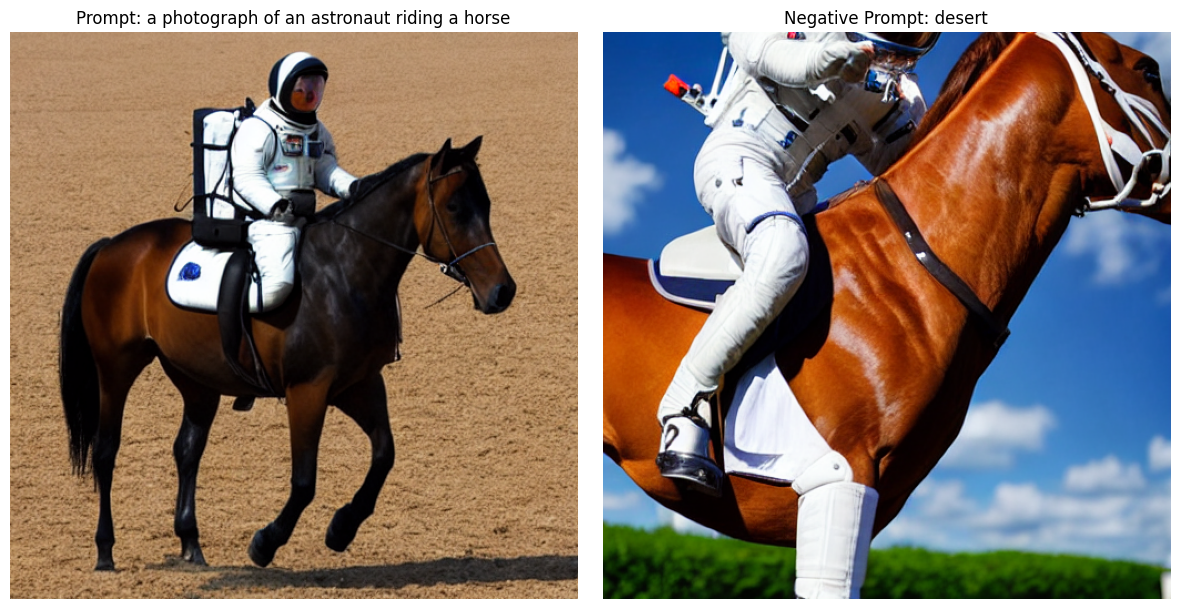

In [16]:
img_pos, img_neg = generate_guided_image(prompt, negative_prompt)

# Plot the images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_pos)
axes[0].axis("off")
axes[0].set_title(f"Prompt: {prompt}")

axes[1].imshow(img_neg)
axes[1].axis("off")
axes[1].set_title(f"Negative Prompt: {negative_prompt}")

plt.tight_layout()
plt.show()


# B. Natural Language Processing Part

## 3 Multi-lingual Translation

### 3.1 Pre-normalization

#### Question 20: Analytical Derivation of Layer Impact on Backpropagation

---

##### **1. Definitions**
Let:
- $ x_\ell $: The input to the current layer.
- $ x_{\ell+1} $: The output of the current layer.
- $ A(x_\ell) $: The self-attention operation.
- $ e $: The error produced during training.

Using the chain rule for backpropagation:
$$
\frac{\partial e}{\partial x_\ell} = \frac{\partial e}{\partial x_L} \cdot \frac{\partial x_L}{\partial x_\ell}.
$$
We need to compute $ \frac{\partial x_{\ell+1}}{\partial x_\ell} $ for both **post-normalization** and **pre-normalization**.

---

##### **2. Post-Normalization**
The output is defined as:
$$
x_{\ell+1} = \text{LayerNorm}(x_\ell + A(x_\ell)).
$$

**Gradient of $ x_{\ell+1} $ with respect to $ x_\ell $:**

Using the chain rule:
$$
\frac{\partial x_{\ell+1}}{\partial x_\ell} = \frac{\partial \text{LayerNorm}(z)}{\partial z} \cdot \frac{\partial z}{\partial x_\ell},
$$
where $ z = x_\ell + A(x_\ell) $.

1. The derivative of $ z $ with respect to $ x_\ell $:
$$
\frac{\partial z}{\partial x_\ell} = I + \frac{\partial A(x_\ell)}{\partial x_\ell}.
$$
Here, $ I $ is the identity matrix (for the residual connection).

2. Substituting back:
$$
\frac{\partial x_{\ell+1}}{\partial x_\ell} = \frac{\partial \text{LayerNorm}(z)}{\partial z} \cdot \left( I + \frac{\partial A(x_\ell)}{\partial x_\ell} \right).
$$

---

##### **3. Pre-Normalization**
The output is defined as:
$$
x_{\ell+1} = x_\ell + A(\text{LayerNorm}(x_\ell)).
$$

**Gradient of $ x_{\ell+1} $ with respect to $ x_\ell $:**

Using the chain rule:
$$
\frac{\partial x_{\ell+1}}{\partial x_\ell} = I + \frac{\partial A(y)}{\partial y} \cdot \frac{\partial y}{\partial x_\ell},
$$
where $ y = \text{LayerNorm}(x_\ell) $.

1. The derivative of $ y $ with respect to $ x_\ell $:
$$
\frac{\partial y}{\partial x_\ell} = \frac{\partial \text{LayerNorm}(x_\ell)}{\partial x_\ell}.
$$

2. Substituting back:
$$
\frac{\partial x_{\ell+1}}{\partial x_\ell} = I + \frac{\partial A(y)}{\partial y} \cdot \frac{\partial \text{LayerNorm}(x_\ell)}{\partial x_\ell}.
$$

---

##### **Final Results**
- **Post-Normalization Gradient**:
$$
\frac{\partial x_{\ell+1}}{\partial x_\ell} = \frac{\partial \text{LayerNorm}(z)}{\partial z} \cdot \left( I + \frac{\partial A(x_\ell)}{\partial x_\ell} \right).
$$
  - The gradient is scaled by the derivative of the layer normalization applied to the combined input and output of the attention layer.
  - This may stabilize training by normalizing the residual connection but can slow convergence due to the normalization acting on the summed inputs.

- **Pre-Normalization Gradient**:
$$
\frac{\partial x_{\ell+1}}{\partial x_\ell} = I + \frac{\partial A(y)}{\partial y} \cdot \frac{\partial \text{LayerNorm}(x_\ell)}{\partial x_\ell}.
$$
  - The gradient flows directly through the residual connection without being normalized, allowing faster convergence but potentially causing instability if gradients are too large.


#### Question 21: Consequences of Using Eq. 32 Instead of Eq. 31 in Training Very Deep Models

<!-- --- -->

<!-- ##### **1. Context**
In deep learning, normalization plays a critical role in stabilizing training by addressing issues such as exploding or vanishing gradients. The choice between **post-normalization** (Eq. 31) and **pre-normalization** (Eq. 32) has significant implications for the backpropagation process and overall model performance. -->

<!-- --- -->

<!-- ##### **1. Implications of Using Eq. 32 (Pre-Normalization)**
Pre-normalization applies the normalization operation before the self-attention mechanism, as shown in Eq. 32. The primary consequences are:

1. **Improved Gradient Flow**:
   - Pre-normalization ensures that the gradients flowing through the network are less prone to extreme values, as the normalization operation directly affects the input to the self-attention layer.
   - This can help mitigate exploding gradients, especially in very deep models, where unnormalized residual connections may amplify gradient values.

2. **Faster Convergence**:
   - By normalizing inputs before applying the attention mechanism, the optimization process benefits from more consistent gradient magnitudes across layers.
   - This can lead to faster convergence during training, particularly in deep architectures where unnormalized inputs may introduce instability.

3. **Potential Instability in Very Deep Models**:
   - Despite the benefits, pre-normalization may introduce subtle instabilities in very deep networks. Since the normalization happens before adding the residual connection, the gradients may still be affected by the unnormalized residual terms during backpropagation.
   - This instability can accumulate in very deep models, potentially leading to training divergence.

---

##### **2. Comparison with Eq. 31 (Post-Normalization)**
Post-normalization, as described in Eq. 31, applies normalization after the self-attention operation and residual connection. The consequences of using Eq. 31 include:

1. **Stabilization of Residual Connections**:
   - Post-normalization stabilizes the combined output of the residual connection and self-attention mechanism, ensuring that the gradients are well-behaved during backpropagation.
   - This is particularly beneficial in very deep models, where residual connections play a critical role in maintaining gradient flow.

2. **Slower Convergence**:
   - By normalizing the combined output, post-normalization can slow down the convergence process, as the gradients are scaled by the normalization operation applied to the entire residual connection and self-attention output.

--- -->
<!-- 
##### **4. Trade-offs in Very Deep Models** -->
Using Eq. 32 (pre-normalization) offers faster convergence and improved gradient flow in moderately deep models. However, in very deep models, the lack of normalization on the residual connection itself can lead to instability. On the other hand, Eq. 31 (post-normalization) provides better stability at the cost of slower convergence. 

For very deep architectures, post-normalization may be preferred due to its ability to stabilize training over many layers.
